# SDHNet — Color Training

Trains the color version of SDHNet (ResNet18, `pretrained=False`) on the 4-class SDH dataset.

This is the baseline model — useful as a ceiling to compare against the grayscale version. The RISE experiment uses the grayscale model (`sdhnet_4class_gray.ipynb`).

Run this notebook in parallel with `sdhnet_4class_gray.ipynb` to halve wall time.

Dataset: `data/sdh_500_clean/` (background-removed, gray composite).

In [1]:
from fastai.vision.all import *
from torchvision.models import resnet18  # explicit import so linters resolve the name

# Auto-pick the largest available dataset. sdh_500 is the target; sdh_200
# is the previous build kept around for quick smoke tests while the
# download_more_images.py + prepare_dataset.py rebuild is in flight.
for candidate in ('data/sdh_500_clean', 'data/sdh_500', 'data/sdh_200'):
    if Path(candidate).exists():
        path = Path(candidate)
        break
else:
    raise FileNotFoundError('No SDH dataset found — run prepare_dataset.py first.')
print(f'Using dataset: {path}')
path.ls()

/Users/ossie/anaconda3/envs/fastbook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset: data/sdh_500_clean


(#2) [Path('data/sdh_500_clean/valid'),Path('data/sdh_500_clean/train')]

## Helper functions

### Choosing a learning rate: `valley` vs. `(min + steep) / 2`

fastai's `lr_find` runs a brief training loop where the learning rate is increased exponentially from tiny (~1e-7) to huge (~1). It records the loss at each step, then offers several heuristics for picking a good LR from the resulting curve.

The earlier prototype notebooks averaged two of these:

- **`lr_steep`** — the LR with the steepest negative gradient ("loss is falling fastest here")
- **`lr_min`** — the LR right before loss starts climbing again ("one step hotter and we diverge")

Averaging them lands halfway between *fastest progress* and *about to blow up* — which is too aggressive, especially for `fit_one_cycle`, which then multiplies that value by ~25× during the warmup phase. With pretrained weights the model is robust enough to survive that overshoot; from random weights it isn't, and we saw `valid_loss` spike to 8.5 in the first three epochs of the ResNet34 run.

**`valley`** is fastai's recommended default for scratch training. It smooths the loss curve, finds the longest contiguous stretch where loss is steadily decreasing, and picks an LR roughly in the middle of that descending segment. The intuition: instead of chasing the *fastest* descent (which sits near the cliff edge), it sits in the *most reliable* descent — well clear of divergence, with safety margin on both sides. For one-cycle training the resulting peak LR stays inside the stable zone even after the warmup multiplier.

In [2]:
def get_lr(learn):
    """Return fastai's `valley` LR suggestion. See the markdown above for why
    we use `valley` instead of the (min+steep)/2 average from earlier prototypes."""
    suggested = learn.lr_find(suggest_funcs=valley)
    lr = float(suggested.valley)
    print(f'Suggested LR (valley): {lr:.6g}')
    return lr

## Color model

Training in color first gives us a ceiling to compare against the grayscale version. If grayscale accuracy is dramatically lower, it may indicate the model is leaning on color cues rather than shape — relevant to interpreting RISE results.

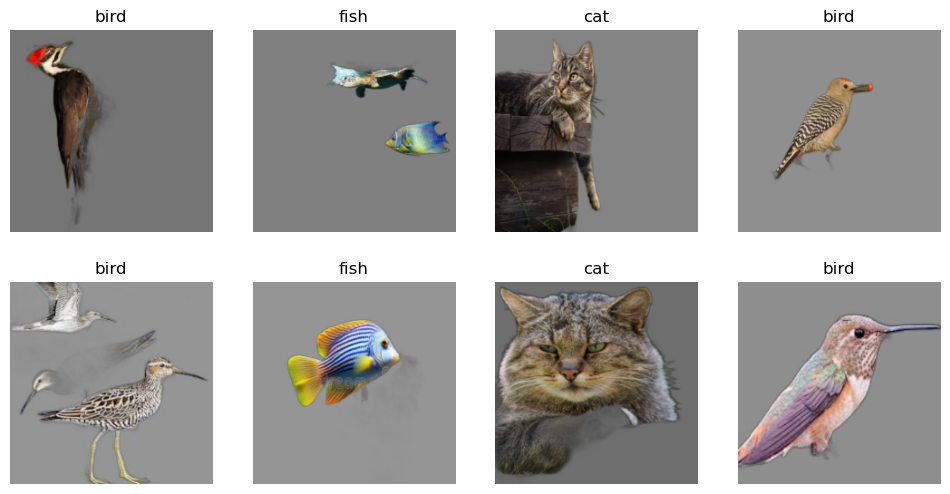

In [3]:
dblock_color = DataBlock(
    blocks      = (ImageBlock, CategoryBlock),
    get_items   = get_image_files,
    get_y       = parent_label,
    splitter    = GrandparentSplitter(train_name='train', valid_name='valid'),
    item_tfms   = RandomResizedCrop(224, min_scale=0.75),
    batch_tfms  = [Flip(), Brightness(max_lighting=0.2), Normalize.from_stats(*imagenet_stats)]
)

dls_color = dblock_color.dataloaders(path, batch_size=32)
dls_color.show_batch(max_n=8, figsize=(12, 6))

In [4]:
print('Classes:', dls_color.vocab)
print('Train size:', len(dls_color.train_ds))
print('Valid size:', len(dls_color.valid_ds))

Classes: ['bird', 'cat', 'fish', 'snake']
Train size: 1600
Valid size: 400


In [5]:
learn_color = vision_learner(
    dls_color,
    resnet18,    # smaller arch (~11M params vs resnet34's ~21M) — better fit for scratch on small data
    metrics=[accuracy, F1Score(average='macro')],
    pretrained=False   # train from scratch — see note below on ImageNet snake synsets
)

Note: using `pretrained=False` (training from scratch) on ResNet18 (smaller than the original ResNet34). ImageNet — what `pretrained=True` would inherit — contains labelled snake synsets (boa constrictor, python, king snake, etc.), so a pretrained model arrives with snake-specific features already baked in. That would confound the experiment: any snake detection advantage we measured could be inherited from human-labelled ImageNet rather than learned by SDHNet on this dataset.

Why ResNet18 over ResNet34 here: with only a few hundred training images per class, ResNet34's ~21M params overfit / underfit (we tried it — clean accuracy plateaued at ~50% on 4 classes). ResNet18's ~11M params is a better match to the data scale.

Trade-off: clean accuracy may still land below a fine-tuned model. We need it reasonable (rough target ~70%+) for the RISE thresholds to be meaningful — if the model can barely classify clean images, the scrambled-image results are noise.

A pretrained-vs-scratch comparison lives in the next notebook (`sdhnet_4class_pretrained_compare.ipynb`). If the scratch model shows no snake advantage but the pretrained one does, that itself is a finding — the advantage was inherited from ImageNet, not learned from pixels.

Suggested LR (valley): 0.000331131


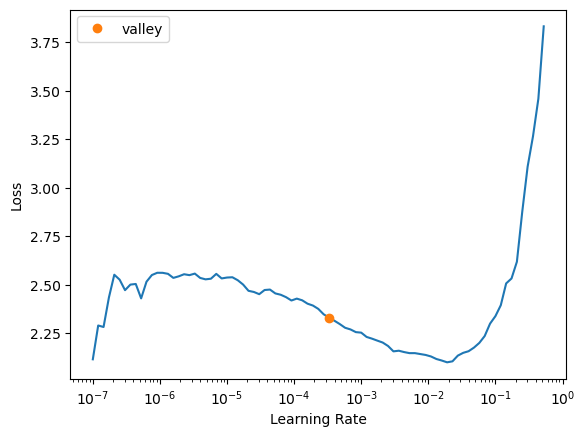

In [6]:
lr_color = get_lr(learn_color)

In [7]:
# Training from scratch — use fit_one_cycle, not fine_tune.
# fine_tune freezes the backbone for an epoch (pointless with random weights)
# and applies discriminative LRs (assumes pretrained early layers).
# Early stopping in case it plateaus before 50 epochs.
cbs = [EarlyStoppingCallback(monitor='valid_loss', min_delta=0.005, patience=8),
       SaveModelCallback(monitor='valid_loss', fname='sdhnet-4class-color-best')]
learn_color.fit_one_cycle(50, lr_color, cbs=cbs)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.168220,1.492867,0.355000,0.321282,00:38
1,1.919618,1.338845,0.497500,0.484186,00:38
2,1.760955,1.300243,0.500000,0.495585,00:35
3,1.648746,1.322938,0.535000,0.522569,00:35
4,1.591486,1.388885,0.527500,0.513062,00:36
5,1.542089,1.546136,0.535000,0.509640,00:35
6,1.510700,1.411085,0.547500,0.545991,00:34
7,1.396796,2.160803,0.442500,0.406179,00:36
8,1.391355,1.285946,0.565000,0.562649,00:35
9,1.315106,1.683273,0.532500,0.505394,00:35


Better model found at epoch 0 with valid_loss value: 1.49286687374115.
Better model found at epoch 1 with valid_loss value: 1.3388450145721436.
Better model found at epoch 2 with valid_loss value: 1.3002432584762573.
Better model found at epoch 8 with valid_loss value: 1.2859455347061157.
Better model found at epoch 11 with valid_loss value: 1.2640714645385742.
Better model found at epoch 14 with valid_loss value: 1.0274385213851929.
Better model found at epoch 19 with valid_loss value: 0.8192511796951294.
Better model found at epoch 23 with valid_loss value: 0.8101553320884705.
Better model found at epoch 28 with valid_loss value: 0.7841808795928955.
Better model found at epoch 31 with valid_loss value: 0.7083178162574768.
Better model found at epoch 32 with valid_loss value: 0.6648557782173157.
Better model found at epoch 38 with valid_loss value: 0.6024649739265442.
No improvement since epoch 38: early stopping


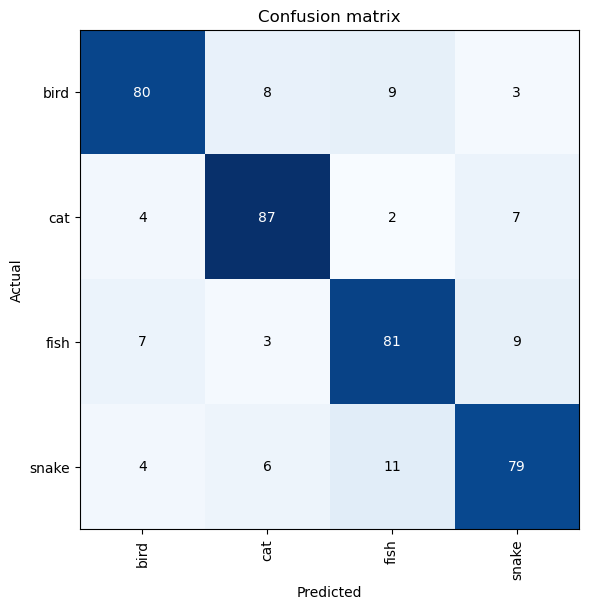

In [8]:
interp_color = ClassificationInterpretation.from_learner(learn_color)
interp_color.plot_confusion_matrix(figsize=(6, 6))

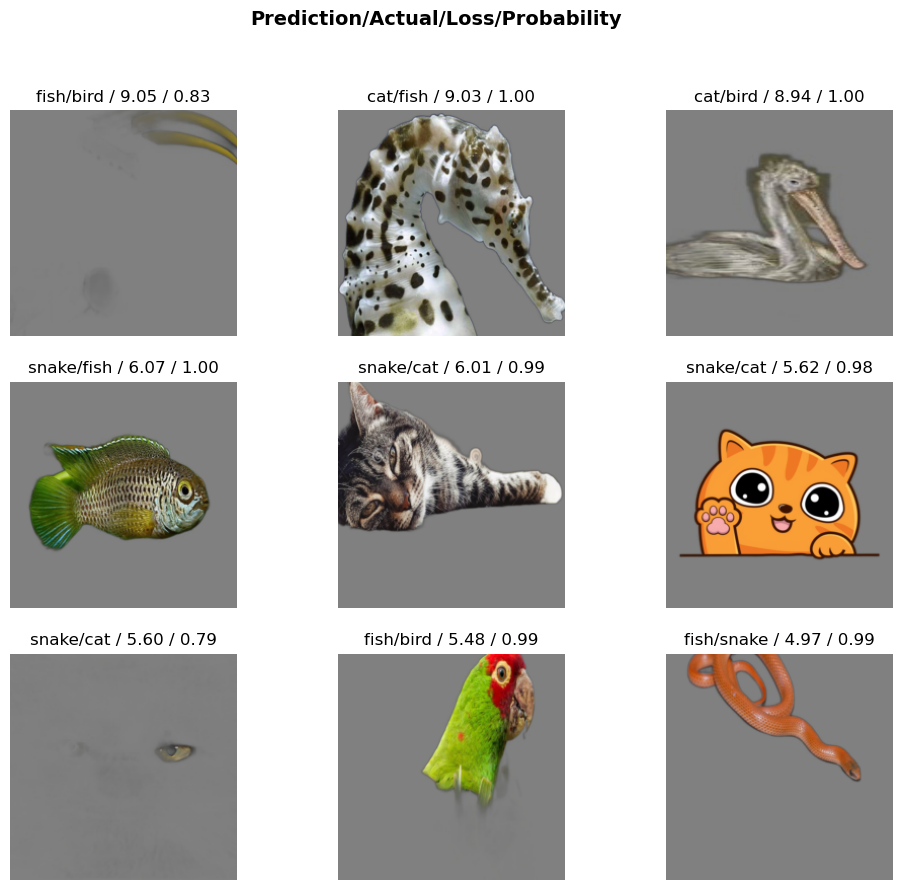

In [9]:
interp_color.plot_top_losses(9, figsize=(12, 10))

In [10]:
learn_color.save('sdhnet-4class-color')
print('Color model saved.')

Color model saved.


In [11]:
interp_color.print_classification_report()

              precision    recall  f1-score   support

        bird       0.84      0.80      0.82       100
         cat       0.84      0.87      0.85       100
        fish       0.79      0.81      0.80       100
       snake       0.81      0.79      0.80       100

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



## Next step

Once the grayscale model (`sdhnet_4class_gray.ipynb`) is also trained, compare metrics side-by-side and proceed to `rise.py` (Phase 3).